<a href="https://colab.research.google.com/github/ervahofi/Speckle-Compute/blob/main/Copy_of_%F0%9F%93%84%F0%9F%96%BC%EF%B8%8F_01_3_Text_to_Image_SDXL_with_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ Text-to-Image SDXL with LoRA

🤗 This notebook uses Hugging Face Diffusers package to create image generation pipelines.

⚠️ **Remember to copy this notebook in your Drive and rename.**

**[Nono Martínez Alonso](https://youtube.com/NonoMartinezAlonso), [James McBennett](https://www.linkedin.com/in/mcbennett/) & [Michal Gryko](https://www.linkedin.com/in/micha%C5%82-gryko-952892131/)**


April 2025

### Mount Drive

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Setup

In [ ]:
%cd /content
!rm -rf creative-image-generation
!git clone https://github.com/nonoesp/creative-image-generation
%cd /content/creative-image-generation/

/content
Cloning into 'creative-image-generation'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 137 (delta 68), reused 104 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 33.36 KiB | 11.12 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/creative-image-generation


In [ ]:
import sys
sys.path.append('/content/creative-image-generation')

In [ ]:
!pip install -q -r requirements.txt --quiet > /dev/null 2>&1

In [ ]:
from config import Config
from utils import set_image_path, save_image, save_meta, save_params_image, save_gif
from IPython.display import Image as IPythonImage
import torch

## Output Directory

In [ ]:
Config.OUTPUT_DIR = "/content/drive/MyDrive/iaac" #e.g "/content/drive/MyDrive/output"

## Load pipeline

Load a pipeline with Hugging Face Diffusers.

In [ ]:
# Create pipeline.
from diffusers import StableDiffusionXLPipeline
pipe = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16)
pipe.to(Config.TORCH_DEVICE)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Load LoRA Links

**ADD MORE LINKS:**

From Hugging face, copy model name from the [top of the page of any LoRA](https://huggingface.co/KappaNeuro/studio-ghibli-style) with username to WEIGHTS_DIR below


Then click "Files and Versions", copy the filename of the .safetensors file to WEIGHTS_NAME

*Don't forget commas when creating new lines

In [ ]:
#add trigger words as comments

LORA = [
    ("KappaNeuro/studio-ghibli-style", "Studio Ghibli Style.safetensors"), #0
    ("TheLastBen/Papercut_SDXL", "papercut.safetensors"),
    ("Fictiverse/Voxel_XL_Lora", "VoxelXL_v1.safetensors"),
    ("ostris/crayon_style_lora_sdxl", "crayons_v1_sdxl.safetensors"),
    ("Norod78/SDXL-VintageMagStyle-Lora", "SDXL-VintageMagStyle-Lora.safetensors"),
    ("artificialguybr/amigurami-redmond-amigurami-crochet-sd-xl-lora", "AmiguramiRedmond-Crochet-Amigurumi.safetensors"), #5
    ("joachimsallstrom/aether-bubbles-foam-lora-for-sdxl", "Aether_Bubbles_And_Foam_v1_SDXL_LoRA.safetensors"),
    ("ProomptEngineer/pe-balloon-diffusion-style", "PE_BalloonStyle.safetensors"),
    ("KappaNeuro/made-of-iridescent-foil", "Made Of Iridescent Foil.safetensors"),
    ("KappaNeuro/ukiyo-e-art", "Ukiyo-e Art.safetensors"),
    ("KappaNeuro/vertical-landscapes", "Vertical Landscapes.safetensors"), #10
    ("KappaNeuro/syd-mead-style", "Syd Mead Style.safetensors"),
    ("KappaNeuro/synthwave-t-shirt", "Synthwave T-shirt.safetensors"),
    ("KappaNeuro/shepard-fairey-style", "Shepard Fairey Style.safetensors"),
    ("KappaNeuro/origami", "ORIGAMI.safetensors"),
    ("KappaNeuro/director-david-fincher-style", "Director David Fincher style.safetensors"), #15
    ("KappaNeuro/director-wes-anderson-style", "Director Wes Anderson style.safetensors"),
    ("ProomptEngineer/pe-neon-sign-style", "PE_NeonSignStyle.safetensors"),
    ("nerijs/pixel-art-xl", "pixel-art-xl.safetensors"),
    ("ostris/ikea-instructions-lora-sdxl", "ikea_instructions_xl_v1_5.safetensors"),
    ("CiroN2022/ascii-art", "ascii_art-sdxl.safetensors"), #20
    ("e-n-v-y/envy-geometric-xl-01", "EnvyGeometricXL01.safetensors"),
    ("KappaNeuro/neon-night", "Neon Night.safetensors"),
    ("KappaNeuro/lascaux", "Lascaux.safetensors"),
    ("e-n-v-y/envy-shadow-minimalism-xl-01", "EnvyShadowMinimalismXL01.safetensors"),
    ("CiroN2022/cyber-background", "Cyber_Background_sdxl.safetensors"), #25
    ("KappaNeuro/beeple-mike-winkelmann-style", "Beeple (Mike Winkelmann) Style.safetensors"),
    ("KappaNeuro/stanley-donwood-style", "Stanley Donwood Style.safetensors"),
    ("KappaNeuro/john-albert-bauer-style", "John Albert Bauer Style.safetensors"),
    ("KappaNeuro/paul-signac-style", "Paul Signac Style.safetensors"),
    ("KappaNeuro/hasui-kawase-style", "Hasui Kawase Style.safetensors"), #30
    ("e-n-v-y/envy-fantasy-art-deco-xl-01", "EnvyFantasyArtDecoXL01.safetensors"),
]

## Config

You can override parameters here.

In [ ]:
SELECT_LORA = 0
print("Selected LoRA:", LORA[SELECT_LORA][0])

#Config.PROMPT = "Neon Night, Ancient Arabian doorway with Heydar Aliyev Center by Zaha Hadid. Busy market with sellers and buyers trading, nighttime sky, camels. Style of nineteenth-century paintings"
Config.PROMPT = 'Macro of jellyfish tentacles near building facade, glowing light interacting with glass panels, sharp textures, ultra-high detail, cinematic realism.'

Config.SEED = 1
Config.STEPS = 50

Config.AUTHOR = 'Erva'
Config.ALGO_TYPE = 'Text to Image'
Config.ALGO_NAME = 'SDXL_LoRA'

Config.check()

Selected LoRA: KappaNeuro/studio-ghibli-style
Config OK.


## Generate

In [87]:
# Load LoRA
pipe.load_lora_weights(LORA[SELECT_LORA][0], weight_name=LORA[SELECT_LORA][1])

### Generate
generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)
image = pipe(Config.PROMPT, num_inference_steps=Config.STEPS, generator=generator).images[0]
set_image_path()

Loading default_19 was unsucessful with the following error: 
CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 4.12 MiB is free. Process 61612 has 14.73 GiB memory in use. Of the allocated memory 13.26 GiB is allocated by PyTorch, and 1.34 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 4.12 MiB is free. Process 61612 has 14.73 GiB memory in use. Of the allocated memory 13.26 GiB is allocated by PyTorch, and 1.34 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Save

Save the pipeline and config metadata, generated image, and the parameters image.

Saved image at /content/drive/MyDrive/iaac/Text-to-Image_SDXL_LoRA/250415_223052_Distant_skyline_at_dawn,_glowing_jellyfish_silhouettes,_layered_depth__steps050.png.


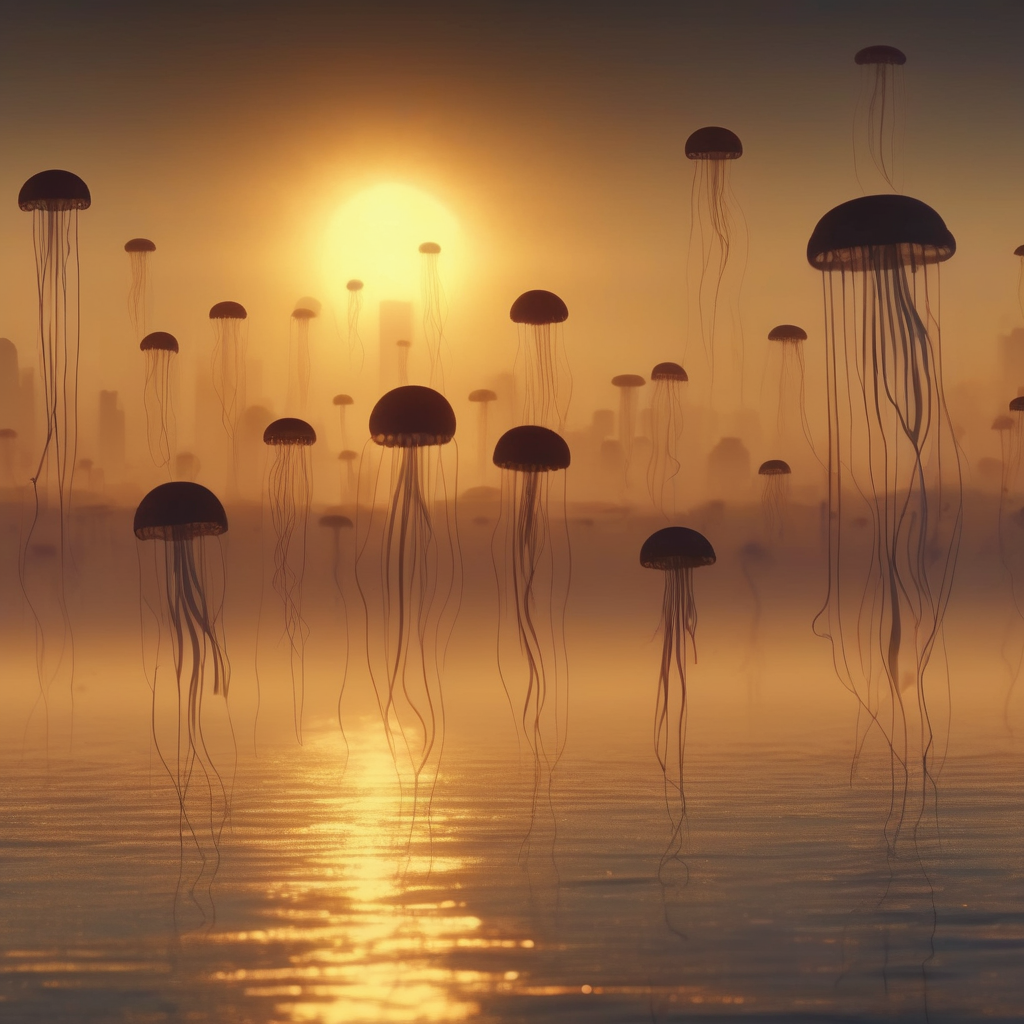

In [ ]:
# Save metadata and image.
save_meta(pipe)
save_image(image)

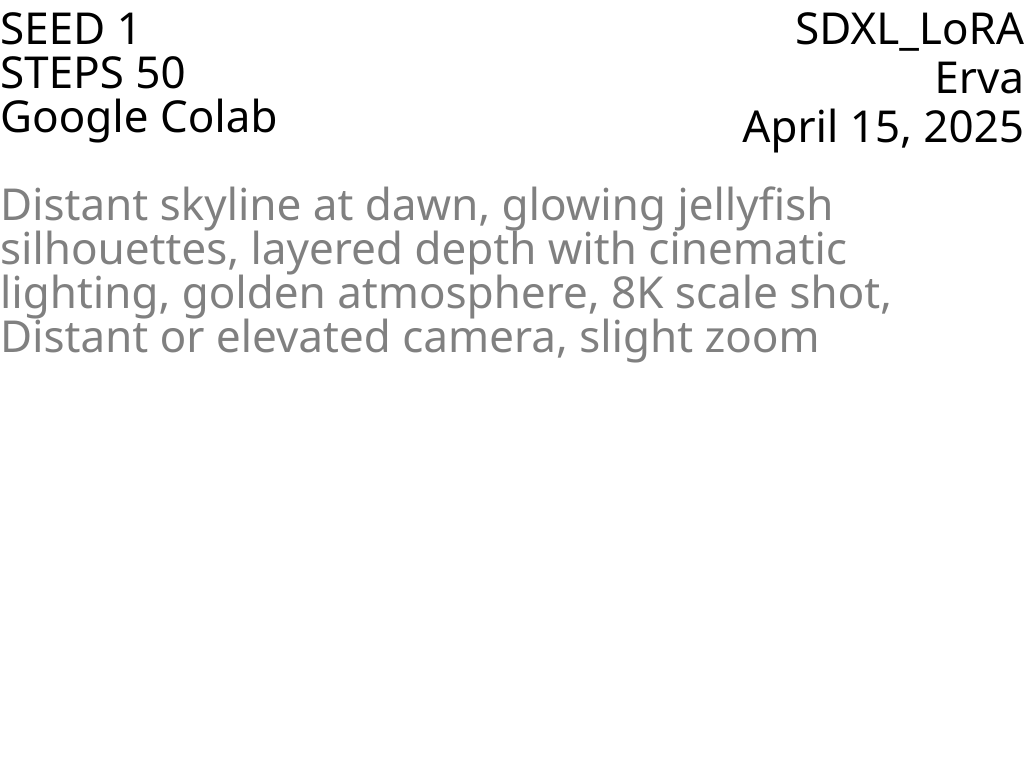

'/content/drive/MyDrive/iaac/Text-to-Image_SDXL_LoRA/250415_223052_Distant_skyline_at_dawn,_glowing_jellyfish_silhouettes,_layered_depth__steps050.svg'

In [ ]:
# Save parameters image.
save_params_image({
    'SEED': Config.SEED,
    'STEPS': Config.STEPS,
    'Google': "Colab"
})

##Alternatively: LoRA Loop (Seed)

In [ ]:
Config.SEED = range(0,20)
SELECT_LORA = 16

# May want to add something about the LoRA at start of the prompt
Config.PROMPT = "Wes Anderson, Ancient Arabian doorway with Heydar Aliyev Center by Zaha Hadid. Busy market with sellers and buyers trading, nighttime sky, camels. Style of nineteenth-century paintings."
frames = []

for seed in Config.SEED:
  ### Choose LoRA from list above using number
  Config.SEED = seed
  print("LoRA Loaded =", WEIGHTS_DIR[SELECT_LORA])
  print("Seed =", seed)
  # Load LoRA
  pipe.load_lora_weights(WEIGHTS_DIR[SELECT_LORA], weight_name=WEIGHTS_NAME[SELECT_LORA])

  ### Generate
  generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)
  image = pipe(Config.PROMPT, num_inference_steps=Config.STEPS, generator=generator).images[0]

  ### Add each image to frames
  frames.append(image)

  ### Set file name, save, and display
  set_image_path()
  save_image(image)
  display(image)

##GIF

In [ ]:
Config.FPS = 3
gif_path = save_gif(frames)
IPythonImage(filename=gif_path)